In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, auc, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

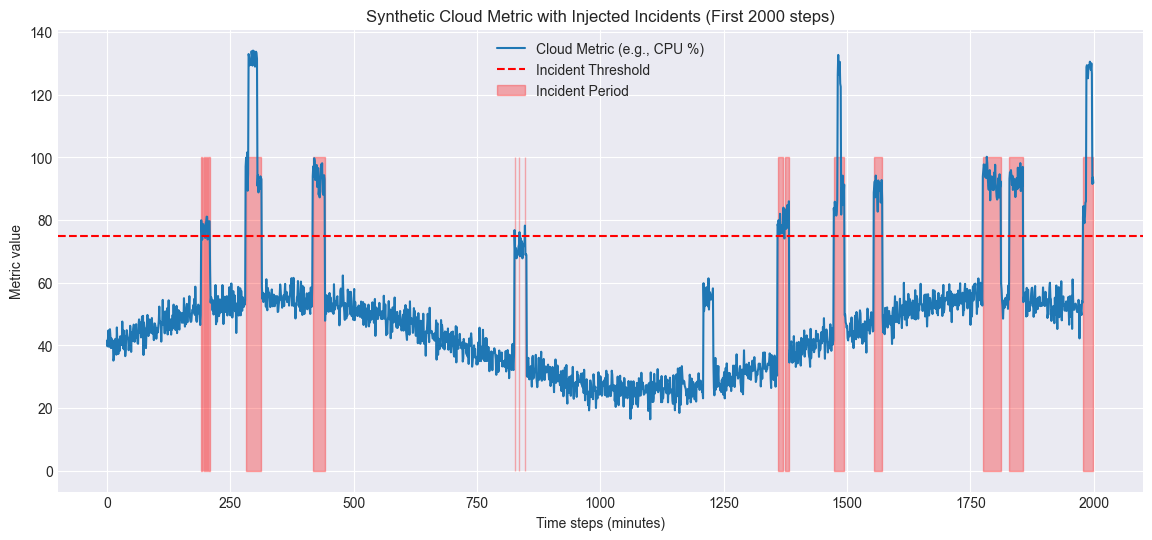

In [17]:
np.random.seed(42)

n_steps = 15000
time = np.arange(n_steps)

seasonality = np.sin(2 * np.pi * time / 1440) * 15
noise = np.random.normal(0, 3, n_steps)
baseline = 40 + seasonality + noise

anomalies = np.zeros(n_steps)
n_anomalies = 60
anomaly_indices = np.random.choice(n_steps - 60, n_anomalies, replace=False)

for idx in anomaly_indices:
    duration = np.random.randint(10, 30)
    anomalies[idx : idx + duration] += np.random.uniform(25, 45)

metric = baseline + anomalies
THRESHOLD = 75

is_incident = (metric > THRESHOLD).astype(int)

plt.plot(time[:2000], metric[:2000], label='Cloud Metric (e.g., CPU %)', color='#1f77b4')
plt.axhline(THRESHOLD, color='red', linestyle='--', label='Incident Threshold')
plt.fill_between(time[:2000], 0, 100, where=is_incident[:2000]==1, color='red', alpha=0.3, label='Incident Period')
plt.title('Synthetic Cloud Metric with Injected Incidents (First 2000 steps)')
plt.xlabel('Time steps (minutes)')
plt.ylabel('Metric value')
plt.legend()
plt.show()

In [18]:
W = 60
H = 15

X, y = [], []

for i in range(len(metric) - W - H + 1):
    window = metric[i : i + W]
    target_window = is_incident[i + W : i + W + H]
    
    X.append(window)
    y.append(1 if np.any(target_window) else 0)

X = np.array(X)
y = np.array(y)

print(f"Input features shape (X): {X.shape}")
print(f"Target labels shape (y): {y.shape}")
print(f"Positive class percentage (alarms): {np.mean(y) * 100:.2f}%")

Input features shape (X): (14926, 60)
Target labels shape (y): (14926,)
Positive class percentage (alarms): 7.98%


In [19]:
split_idx = int(len(X) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Area Under PR Curve (PR-AUC): 0.450
To achieve ~80% Recall, the alert threshold must be set to: 0.020


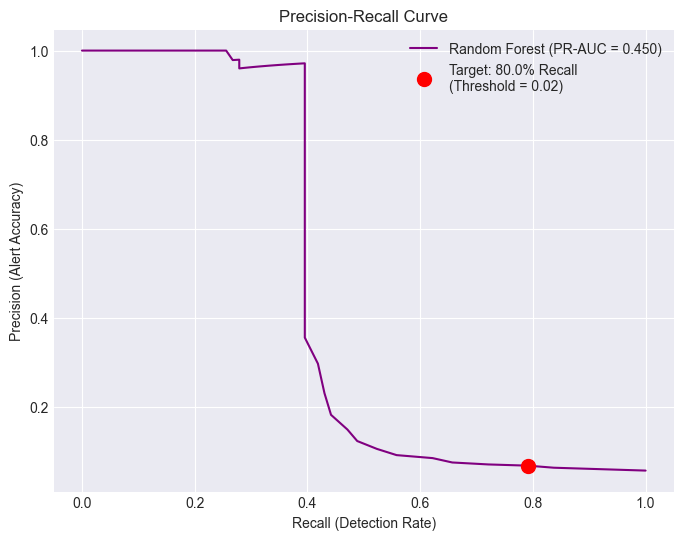

In [20]:
y_probs = model.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)
pr_auc = auc(recalls, precisions)

target_recall = 0.80
idx = np.argmin(np.abs(recalls - target_recall))
optimal_threshold = thresholds[idx]

print(f"Area Under PR Curve (PR-AUC): {pr_auc:.3f}")
print(f"To achieve ~80% Recall, the alert threshold must be set to: {optimal_threshold:.3f}")

plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, label=f'Random Forest (PR-AUC = {pr_auc:.3f})', color='purple')
plt.plot(recalls[idx], precisions[idx], 'ro', markersize=10, 
         label=f'Target: {target_recall*100}% Recall\n(Threshold = {optimal_threshold:.2f})')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall (Detection Rate)')
plt.ylabel('Precision (Alert Accuracy)')
plt.legend()
plt.show()

Classification report for optimized threshold (Recall ~80%):

              precision    recall  f1-score   support

           0       0.96      0.34      0.51      2814
           1       0.07      0.79      0.13       172

    accuracy                           0.37      2986
   macro avg       0.52      0.57      0.32      2986
weighted avg       0.91      0.37      0.49      2986



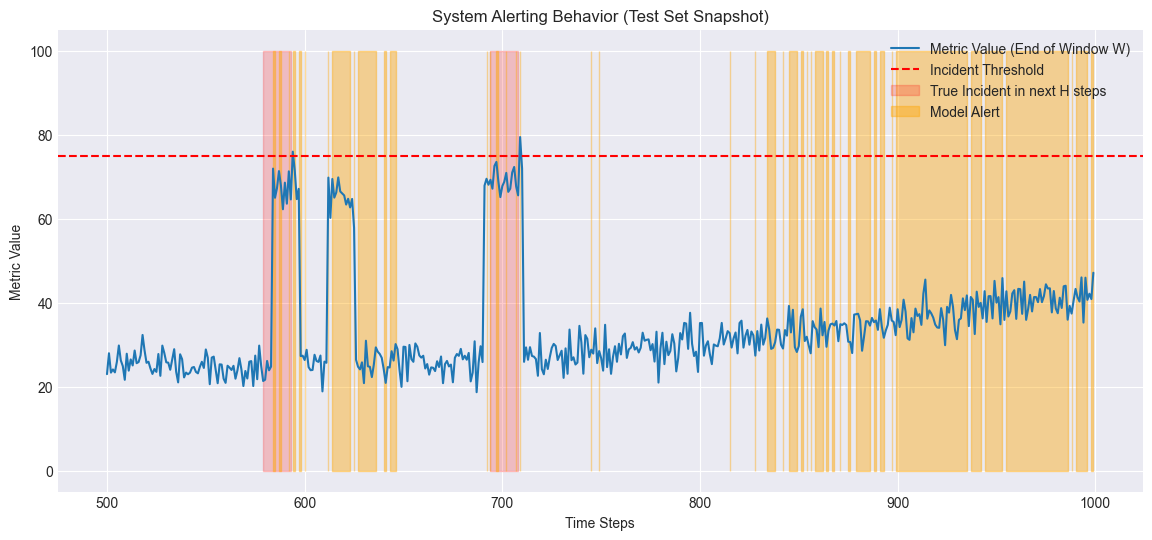

In [21]:
y_pred_optimal = (y_probs >= optimal_threshold).astype(int)

print("Classification report for optimized threshold (Recall ~80%):\n")
print(classification_report(y_test, y_pred_optimal))

start_plot, end_plot = 500, 1000

plt.plot(np.arange(start_plot, end_plot), X_test[start_plot:end_plot, -1], label='Metric Value (End of Window W)')
plt.axhline(THRESHOLD, color='red', linestyle='--', label='Incident Threshold')

plt.fill_between(np.arange(start_plot, end_plot), 0, 100, 
                 where=y_test[start_plot:end_plot]==1, color='red', alpha=0.2, label='True Incident in next H steps')

plt.fill_between(np.arange(start_plot, end_plot), 0, 100, 
                 where=y_pred_optimal[start_plot:end_plot]==1, color='orange', alpha=0.4, label='Model Alert')

plt.title('System Alerting Behavior (Test Set Snapshot)')
plt.xlabel('Time Steps')
plt.ylabel('Metric Value')
plt.legend(loc='upper right')
plt.show()